In [ ]:
pip install yfinance pandas numpy scikit-learn

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [12]:
# --- 1. Arsitektur IT2-ANFIS ---
class IT2_ANFIS:
    def __init__(self, n_inputs, n_mf):
        self.n_inputs = n_inputs
        self.n_mf = n_mf
        self.n_rules = n_mf ** n_inputs
        self.n_ant_params = n_inputs * n_mf * 3
        self.n_cons_params = self.n_rules * (n_inputs + 1)
        self.total_params = self.n_ant_params + self.n_cons_params

    def forward(self, X, params):
        ant_params = params[:self.n_ant_params].reshape(self.n_inputs, self.n_mf, 3)
        cons_params = params[self.n_ant_params:].reshape(self.n_rules, self.n_inputs + 1)

        N = X.shape[0]
        mu_low = np.zeros((N, self.n_inputs, self.n_mf))
        mu_up = np.zeros((N, self.n_inputs, self.n_mf))

        for i in range(self.n_inputs):
            for j in range(self.n_mf):
                c, s1, s2 = ant_params[i, j]
                s_min, s_max = abs(min(s1, s2)), abs(max(s1, s2))
                mu_low[:, i, j] = np.exp(-0.5 * ((X[:, i] - c) / (s_min + 1e-9))**2)
                mu_up[:, i, j] = np.exp(-0.5 * ((X[:, i] - c) / (s_max + 1e-9))**2)

        w_low = np.ones((N, self.n_rules))
        w_up = np.ones((N, self.n_rules))

        grid = np.meshgrid(*[np.arange(self.n_mf) for _ in range(self.n_inputs)])
        rule_idx = np.stack(grid, axis=-1).reshape(-1, self.n_inputs)

        for k in range(self.n_rules):
            for i in range(self.n_inputs):
                mf_idx = rule_idx[k, i]
                w_low[:, k] *= mu_low[:, i, mf_idx]
                w_up[:, k] *= mu_up[:, i, mf_idx]

        X_with_bias = np.hstack([X, np.ones((N, 1))])
        f = X_with_bias @ cons_params.T

        # --- Type Reduction: Karnik-Mendel (KM) ---
        y_pred = np.zeros(N)

        for idx in range(N):
            f_row = f[idx]
            w_l_row = w_low[idx]
            w_u_row = w_up[idx]

            sort_idx = np.argsort(f_row)
            f_s = f_row[sort_idx]
            w_l_s = w_l_row[sort_idx]
            w_u_s = w_u_row[sort_idx]

            w_init = (w_l_s + w_u_s) / 2

            # Menghitung y_left (y_l)
            y_prime = np.sum(f_s * w_init) / (np.sum(w_init) + 1e-9)
            for _ in range(15):
                L = np.searchsorted(f_s, y_prime) - 1
                L = max(0, min(L, len(f_s) - 2))
                w_temp = np.concatenate([w_u_s[:L+1], w_l_s[L+1:]])
                y_new = np.sum(f_s * w_temp) / (np.sum(w_temp) + 1e-9)
                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            y_left = y_prime

            # Menghitung y_right (y_r)
            y_prime = np.sum(f_s * w_init) / (np.sum(w_init) + 1e-9)
            for _ in range(15):
                R = np.searchsorted(f_s, y_prime) - 1
                R = max(0, min(R, len(f_s) - 2))
                w_temp = np.concatenate([w_l_s[:R+1], w_u_s[R+1:]])
                y_new = np.sum(f_s * w_temp) / (np.sum(w_temp) + 1e-9)
                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            y_right = y_prime

            y_pred[idx] = (y_left + y_right) / 2

        return y_pred

# --- 2. Fungsi Evaluasi ---
def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def calculate_accuracy(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9)))
    return max(0, (1 - mape) * 100)

# --- 3. Optimasi Standar IT2-ANFIS (Gradient Descent / Backpropagation) ---
def gradient_descent_optimize(model, X, y, epochs=50, learning_rate=0.01):
    """
    Optimasi IT2-ANFIS menggunakan Gradient Descent dengan gradien ANALITIK EKSAK.

    Derivasi gradien diterapkan secara analitik melalui seluruh komputasi:
      1. MSE Loss  →  ∂L/∂ŷ = 2(ŷ - y) / N
      2. y_pred = (y_L + y_R) / 2  →  ∂ŷ/∂y_L = ∂ŷ/∂y_R = 0.5
      3. y_L = Σ(f·w_tL) / Σ(w_tL)  (hasil KM yang sudah konvergen)
           →  ∂y_L/∂f[k]    = w_tL[k] / Σ(w_tL)
           →  ∂y_L/∂w_tL[k] = (f[k] - y_L) / Σ(w_tL)
         (identik untuk y_R dengan w_tR)
      4. Penugasan bobot KM (switch point L, R diperlakukan konstan):
           w_tL[k] = w_up[k] jika k ≤ L, else w_low[k]   (dalam urutan terurut f)
           w_tR[k] = w_low[k] jika k ≤ R, else w_up[k]
      5. f[k] = X_bias @ cons_params[k]
           →  ∂L/∂cons_params[k] = ∂L/∂f[k] · X_bias
      6. w_low[k] = Π_i μ_low[i, rule_idx[k,i]]  (aturan produk)
           →  ∂w_low[k]/∂μ_low[i,j] = w_low[k] / μ_low[i,j]
      7. μ_low[i,j] = exp(-0.5 · ((x_i - c) / s_min)²)
           →  ∂μ/∂c     = μ · (x_i - c) / s_min²
           →  ∂μ/∂s_min = μ · (x_i - c)² / s_min³
         Dengan chain rule ke s1, s2 via s_min = |min(s1,s2)|, s_max = |max(s1,s2)|.

    Catatan: switch point L dan R pada algoritma Karnik-Mendel bersifat diskret
    (tidak dapat didiferensiasi). Pendekatan standar (digunakan di sini) adalah
    memperlakukan L dan R sebagai konstanta setelah forward pass konvergen,
    kemudian menerapkan turunan analitik penuh pada ekspresi weighted-average
    yang dihasilkan. Ini menghasilkan gradien eksak — bukan aproksimasi —
    pada setiap titik diferensiabel dalam ruang parameter.
    """
    N = X.shape[0]
    dim = model.total_params
    params = np.random.uniform(-1, 1, dim)
    X_bias = np.hstack([X, np.ones((N, 1))])  # (N, n_inputs+1)

    # Precompute rule_idx sekali (tidak berubah antar epoch)
    grid = np.meshgrid(*[np.arange(model.n_mf) for _ in range(model.n_inputs)])
    rule_idx = np.stack(grid, axis=-1).reshape(-1, model.n_inputs)  # (n_rules, n_inputs)

    for epoch in range(epochs):

        # =====================================================================
        # FORWARD PASS — simpan semua intermediate values untuk backward pass
        # =====================================================================
        ant_params  = params[:model.n_ant_params].reshape(model.n_inputs, model.n_mf, 3)
        cons_params = params[model.n_ant_params:].reshape(model.n_rules, model.n_inputs + 1)

        # --- Layer 1: Membership functions (Gaussian IT2) ---
        mu_low   = np.zeros((N, model.n_inputs, model.n_mf))
        mu_up    = np.zeros((N, model.n_inputs, model.n_mf))
        s_min_saved = np.zeros((model.n_inputs, model.n_mf))
        s_max_saved = np.zeros((model.n_inputs, model.n_mf))

        for i in range(model.n_inputs):
            for j in range(model.n_mf):
                c, s1, s2 = ant_params[i, j]
                s_min = abs(min(s1, s2)) + 1e-9
                s_max = abs(max(s1, s2)) + 1e-9
                s_min_saved[i, j] = s_min
                s_max_saved[i, j] = s_max
                diff = X[:, i] - c                          # (N,)
                mu_low[:, i, j] = np.exp(-0.5 * (diff / s_min) ** 2)
                mu_up[:, i, j]  = np.exp(-0.5 * (diff / s_max) ** 2)

        # --- Layer 2: Rule firing strengths (produk MF tiap input) ---
        w_low = np.ones((N, model.n_rules))
        w_up  = np.ones((N, model.n_rules))

        for k in range(model.n_rules):
            for i in range(model.n_inputs):
                mf = rule_idx[k, i]
                w_low[:, k] *= mu_low[:, i, mf]
                w_up[:, k]  *= mu_up[:, i, mf]

        # --- Layer 3: Consequent outputs ---
        f = X_bias @ cons_params.T  # (N, n_rules)

        # --- Layer 4: KM Type Reduction ---
        y_pred = np.zeros(N)
        km_cache = []  # simpan data per-sampel untuk backward pass

        for idx in range(N):
            f_row   = f[idx]
            w_l_row = w_low[idx]
            w_u_row = w_up[idx]

            sort_idx = np.argsort(f_row)
            inv_sort = np.argsort(sort_idx)  # inverse permutation (untuk unsort)
            f_s  = f_row[sort_idx]
            w_ls = w_l_row[sort_idx]
            w_us = w_u_row[sort_idx]

            w_init     = (w_ls + w_us) / 2
            denom_init = np.sum(w_init) + 1e-9

            # -- Hitung y_left --
            y_prime = np.dot(f_s, w_init) / denom_init
            L_final, w_tL = 0, w_init.copy()
            for _ in range(15):
                L = np.searchsorted(f_s, y_prime) - 1
                L = max(0, min(L, model.n_rules - 2))
                w_t = np.concatenate([w_us[:L+1], w_ls[L+1:]])
                y_new = np.dot(f_s, w_t) / (np.sum(w_t) + 1e-9)
                L_final, w_tL = L, w_t
                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            sum_wL = np.sum(w_tL) + 1e-9
            y_left = np.dot(f_s, w_tL) / sum_wL

            # -- Hitung y_right --
            y_prime = np.dot(f_s, w_init) / denom_init
            R_final, w_tR = 0, w_init.copy()
            for _ in range(15):
                R = np.searchsorted(f_s, y_prime) - 1
                R = max(0, min(R, model.n_rules - 2))
                w_t = np.concatenate([w_ls[:R+1], w_us[R+1:]])
                y_new = np.dot(f_s, w_t) / (np.sum(w_t) + 1e-9)
                R_final, w_tR = R, w_t
                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            sum_wR = np.sum(w_tR) + 1e-9
            y_right = np.dot(f_s, w_tR) / sum_wR

            y_pred[idx] = (y_left + y_right) / 2

            km_cache.append(dict(
                sort_idx=sort_idx, inv_sort=inv_sort,
                f_s=f_s, w_tL=w_tL, w_tR=w_tR,
                y_left=y_left, y_right=y_right,
                sum_wL=sum_wL, sum_wR=sum_wR,
                L=L_final, R=R_final,
            ))

        # --- Loss (MSE) ---
        error = y_pred - y
        rmse  = np.sqrt(np.mean(error ** 2))

        # =====================================================================
        # BACKWARD PASS — gradien analitik eksak
        # =====================================================================
        grad_cons  = np.zeros_like(cons_params)  # ∂L/∂cons_params
        grad_w_low = np.zeros((N, model.n_rules)) # ∂L/∂w_low
        grad_w_up  = np.zeros((N, model.n_rules)) # ∂L/∂w_up

        # ∂L/∂ŷ = 2(ŷ - y) / N   (MSE)
        dL_dy = 2.0 * error / N  # (N,)

        for idx in range(N):
            d     = dL_dy[idx]
            km    = km_cache[idx]
            f_s   = km['f_s']
            w_tL  = km['w_tL']
            w_tR  = km['w_tR']
            y_L   = km['y_left']
            y_R   = km['y_right']
            swL   = km['sum_wL']
            swR   = km['sum_wR']
            L     = km['L']
            R     = km['R']
            si    = km['sort_idx']   # original_rule_idx = si[ks]
            iv    = km['inv_sort']   # sorted_pos of rule k = iv[k]

            # --- ∂L/∂f_s[ks]  (gradien terhadap output consequent, terurut) ---
            # y_pred = 0.5*(y_L + y_R),  y_L = Σ(f_s·w_tL)/swL
            # ∂y_L/∂f_s[ks] = w_tL[ks] / swL
            df_s = d * 0.5 * (w_tL / swL + w_tR / swR)  # (n_rules,)

            # --- ∂L/∂w_tL[ks] dan ∂L/∂w_tR[ks] ---
            # ∂y_L/∂w_tL[ks] = (f_s[ks] - y_L) / swL
            dw_tL = d * 0.5 * (f_s - y_L) / swL  # (n_rules,)
            dw_tR = d * 0.5 * (f_s - y_R) / swR  # (n_rules,)

            # --- Akumulasi ∂L/∂cons_params ---
            # f[idx, k] = X_bias[idx] @ cons_params[k]  →  ∂/∂cons_params[k] = X_bias[idx]
            # Unsort: gradien untuk rule k berada di posisi iv[k] dalam urutan terurut
            df_orig = df_s[iv]  # (n_rules,), urutan rule asli
            grad_cons += np.outer(df_orig, X_bias[idx])

            # --- Akumulasi ∂L/∂w_low dan ∂L/∂w_up ---
            # Penugasan KM (dalam urutan terurut):
            #   w_tL[ks] = w_us[ks] jika ks <= L, else w_ls[ks]
            #   w_tR[ks] = w_ls[ks] jika ks <= R, else w_us[ks]
            for ks in range(model.n_rules):
                orig_k = si[ks]
                # Dari w_tL
                if ks <= L:
                    grad_w_up[idx, orig_k]  += dw_tL[ks]
                else:
                    grad_w_low[idx, orig_k] += dw_tL[ks]
                # Dari w_tR
                if ks <= R:
                    grad_w_low[idx, orig_k] += dw_tR[ks]
                else:
                    grad_w_up[idx, orig_k]  += dw_tR[ks]

        # --- ∂L/∂μ_low dan ∂L/∂μ_up melalui aturan produk ---
        # w_low[idx,k] = Π_i μ_low[idx, i, rule_idx[k,i]]
        # ∂w_low[idx,k]/∂μ_low[idx,i,j] = w_low[idx,k] / μ_low[idx,i,j]  (jika j == rule_idx[k,i])
        grad_mu_low = np.zeros_like(mu_low)  # (N, n_inputs, n_mf)
        grad_mu_up  = np.zeros_like(mu_up)

        for k in range(model.n_rules):
            for i in range(model.n_inputs):
                mf = rule_idx[k, i]
                safe_low = np.maximum(mu_low[:, i, mf], 1e-300)
                safe_up  = np.maximum(mu_up[:, i, mf],  1e-300)
                grad_mu_low[:, i, mf] += grad_w_low[:, k] * w_low[:, k] / safe_low
                grad_mu_up[:, i, mf]  += grad_w_up[:, k]  * w_up[:, k]  / safe_up

        # --- ∂L/∂ant_params (c, s1, s2) melalui Gaussian ---
        # μ = exp(-0.5·((x-c)/s)²)
        # ∂μ/∂c     =  μ·(x-c)/s²
        # ∂μ/∂s     =  μ·(x-c)²/s³
        # Chain rule ke s1, s2 via s_min=|min(s1,s2)|, s_max=|max(s1,s2)|:
        #   jika s1 ≤ s2: ds_min/ds1 = sign(s1), ds_max/ds2 = sign(s2)
        #   jika s1 > s2: ds_min/ds2 = sign(s2), ds_max/ds1 = sign(s1)
        grad_ant = np.zeros_like(ant_params)  # (n_inputs, n_mf, 3)

        for i in range(model.n_inputs):
            for j in range(model.n_mf):
                c, s1, s2 = ant_params[i, j]
                s_min = s_min_saved[i, j]
                s_max = s_max_saved[i, j]
                diff  = X[:, i] - c  # (N,)

                # Turunan parsial μ terhadap c dan s (semua sampel sekaligus)
                dmu_low_dc    = mu_low[:, i, j] * diff / s_min ** 2
                dmu_low_dsmin = mu_low[:, i, j] * diff ** 2 / s_min ** 3
                dmu_up_dc     = mu_up[:, i, j]  * diff / s_max ** 2
                dmu_up_dsmax  = mu_up[:, i, j]  * diff ** 2 / s_max ** 3

                # ∂L/∂c = Σ_n [ ∂L/∂μ_low · ∂μ_low/∂c + ∂L/∂μ_up · ∂μ_up/∂c ]
                grad_ant[i, j, 0] = np.sum(
                    grad_mu_low[:, i, j] * dmu_low_dc +
                    grad_mu_up[:, i, j]  * dmu_up_dc
                )

                dL_dsmin = np.sum(grad_mu_low[:, i, j] * dmu_low_dsmin)
                dL_dsmax = np.sum(grad_mu_up[:, i, j]  * dmu_up_dsmax)

                # Chain rule: s_min dan s_max ke s1, s2
                if s1 <= s2:
                    # s_min berasal dari s1, s_max dari s2
                    ds_min_ds1 = np.sign(s1) if s1 != 0 else 0.0
                    ds_max_ds2 = np.sign(s2) if s2 != 0 else 0.0
                    grad_ant[i, j, 1] = dL_dsmin * ds_min_ds1
                    grad_ant[i, j, 2] = dL_dsmax * ds_max_ds2
                else:
                    # s_min berasal dari s2, s_max dari s1
                    ds_min_ds2 = np.sign(s2) if s2 != 0 else 0.0
                    ds_max_ds1 = np.sign(s1) if s1 != 0 else 0.0
                    grad_ant[i, j, 1] = dL_dsmax * ds_max_ds1
                    grad_ant[i, j, 2] = dL_dsmin * ds_min_ds2

        # --- Gabungkan gradien dan update parameter ---
        grad_params = np.concatenate([grad_ant.flatten(), grad_cons.flatten()])
        params -= learning_rate * grad_params

        print(f"Epoch {epoch+1}/{epochs} - RMSE: {rmse:.6f}")

    return params

In [13]:
# --- 4. Data Preparation (Yahoo Finance) ---
def load_bitcoin_data(lookback=3):
    print("Mengambil data Bitcoin...")
    df = yf.download('BTC-USD', start='2021-01-01', interval='1d', end = '2025-12-31')
    data = df['Close'].values.reshape(-1, 1)

    # Normalisasi ke range [0, 1]
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    # Membuat dataset Time Series (X = harga t-3, t-2, t-1; y = harga t)
    X, y = [], []
    for i in range(len(scaled_data) - lookback):
        X.append(scaled_data[i : i + lookback, 0])
        y.append(scaled_data[i + lookback, 0])

    X, y = np.array(X), np.array(y)

    # Split Data: 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test, scaler



[*********************100%***********************]  1 of 1 completed

Mengambil data Bitcoin...
Melatih model dengan 1454 data...


Epoch 1/100 - RMSE: 0.293361
Epoch 2/100 - RMSE: 0.306543
Epoch 3/100 - RMSE: 0.147423
Epoch 4/100 - RMSE: 0.103536
Epoch 5/100 - RMSE: 0.078711
Epoch 6/100 - RMSE: 0.065858
Epoch 7/100 - RMSE: 0.057629
Epoch 8/100 - RMSE: 0.051918
Epoch 9/100 - RMSE: 0.047722
Epoch 10/100 - RMSE: 0.044513
Epoch 11/100 - RMSE: 0.041926
Epoch 12/100 - RMSE: 0.039796
Epoch 13/100 - RMSE: 0.038026
Epoch 14/100 - RMSE: 0.036518
Epoch 15/100 - RMSE: 0.035211
Epoch 16/100 - RMSE: 0.034062
Epoch 17/100 - RMSE: 0.033041
Epoch 18/100 - RMSE: 0.032108
Epoch 19/100 - RMSE: 0.031252
Epoch 20/100 - RMSE: 0.030476
Epoch 21/100 - RMSE: 0.029766
Epoch 22/100 - RMSE: 0.029110
Epoch 23/100 - RMSE: 0.028502
Epoch 24/100 - RMSE: 0.027936
Epoch 25/100 - RMSE: 0.027406
Epoch 26/100 - RMSE: 0.026912
Epoch 27/100 - RMSE: 0.026452
Epoch 28/100 - RMSE: 0.026023
Epoch 29/100 - RMSE: 0.025622
Epoch 30/100 - RMSE: 0.025245
Epoch 31/100 - RMSE: 0.024893
Epoch 32/100 - RMSE: 0.024562
Epoch 33/100 - RMSE: 0.024251
Epoch 34/100 - RMSE

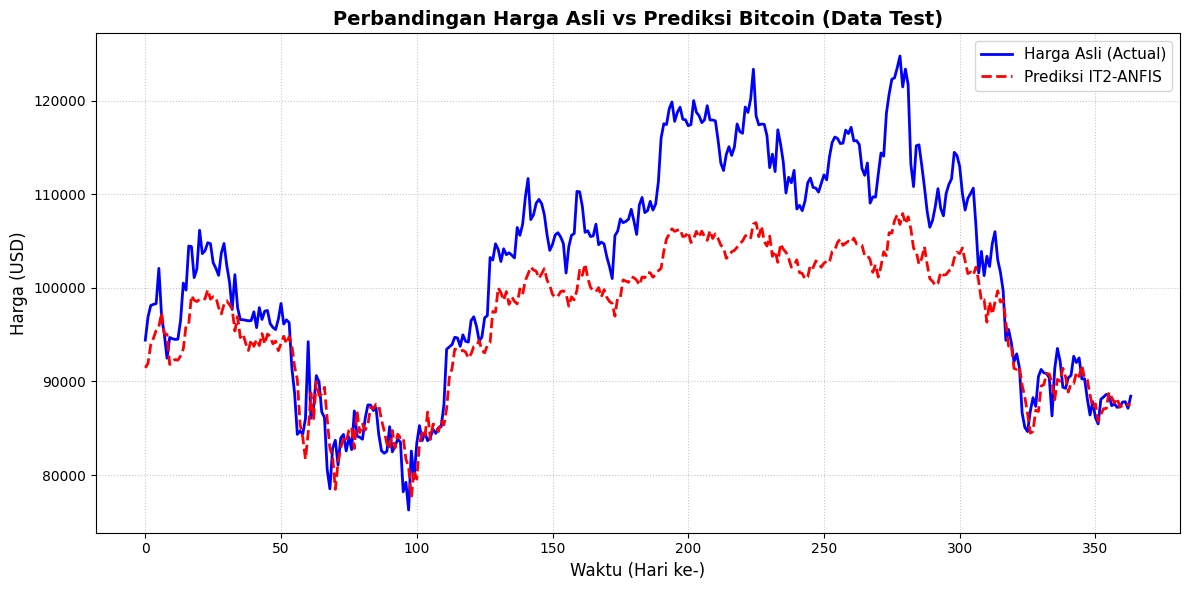

Runtime: 0 menit 20.31 detik


In [25]:
start = time.time()
# --- 5. Main Execution ---
if __name__ == "__main__":
    LOOKBACK = 7 # Menggunakan 7 hari sebelumnya untuk prediksi

    # Asumsi fungsi load_bitcoin_data sudah didefinisikan sebelumnya
    X_train, X_test, y_train, y_test, scaler = load_bitcoin_data(lookback=LOOKBACK)

    # Inisialisasi Model (Input sesuai LOOKBACK, 2 MF per input)
    model = IT2_ANFIS(n_inputs=LOOKBACK, n_mf=2)

    print(f"Melatih model dengan {X_train.shape[0]} data...")
    # --- MENGGUNAKAN GRADIENT DESCENT ---
    # Anda bisa menyesuaikan nilai epochs dan learning_rate sesuai kebutuhan
    best_params = gradient_descent_optimize(model, X_train, y_train, epochs=100, learning_rate=0.52)

    # Prediksi pada Data Test
    y_pred_scaled = model.forward(X_test, best_params)

    # Denormalisasi untuk melihat harga asli
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_real = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Metrik Akhir
    rmse = calculate_rmse(y_test_real, y_pred_real)
    accuracy = calculate_accuracy(y_test_real, y_pred_real)

    print("\n" + "="*30)
    print("HASIL PREDIKSI BITCOIN (DATA TEST)")
    print(f"RMSE    : ${rmse:.2f}")
    print(f"Akurasi : {accuracy:.2f} %")
    print("="*30)

    # Contoh tampilan 5 prediksi terakhir
    print("\n5 Prediksi Terakhir vs Harga Asli:")
    for i in range(-5, 0):
        print(f"Asli: ${y_test_real[i]:.2f} | Prediksi: ${y_pred_real[i]:.2f}")

    # --- 6. Visualisasi Hasil ---
    print("\nMenampilkan grafik visualisasi...")
    plt.figure(figsize=(12, 6))

    # Plot harga asli (warna biru, garis tegas)
    plt.plot(y_test_real, label='Harga Asli (Actual)', color='blue', linewidth=2)

    # Plot harga prediksi (warna merah, garis putus-putus)
    plt.plot(y_pred_real, label='Prediksi IT2-ANFIS', color='red', linestyle='--', linewidth=2)

    # Konfigurasi tampilan grafik
    plt.title('Perbandingan Harga Asli vs Prediksi Bitcoin (Data Test)', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Hari ke-)', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    # Tampilkan grafik
    plt.show()
end = time.time()

elapsed = end - start
print(f"Runtime: {int(elapsed//60)} menit {elapsed%60:.2f} detik")

/tmp/ipykernel_7559/629796991.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2021-01-01', interval='1d', end = '2021-12-31')
[*********************100%***********************]  1 of 1 completed

Mengambil data Bitcoin...
Melatih model dengan 288 data...


Epoch 1/50 - RMSE: 0.378524
Epoch 2/50 - RMSE: 0.373542
Epoch 3/50 - RMSE: 0.368732
Epoch 4/50 - RMSE: 0.364033
Epoch 5/50 - RMSE: 0.359397
Epoch 6/50 - RMSE: 0.354770
Epoch 7/50 - RMSE: 0.350092
Epoch 8/50 - RMSE: 0.345299
Epoch 9/50 - RMSE: 0.340307
Epoch 10/50 - RMSE: 0.335013
Epoch 11/50 - RMSE: 0.329280
Epoch 12/50 - RMSE: 0.322918
Epoch 13/50 - RMSE: 0.315655
Epoch 14/50 - RMSE: 0.307099
Epoch 15/50 - RMSE: 0.296677
Epoch 16/50 - RMSE: 0.283527
Epoch 17/50 - RMSE: 0.266683
Epoch 18/50 - RMSE: 0.245350
Epoch 19/50 - RMSE: 0.221519
Epoch 20/50 - RMSE: 0.195639
Epoch 21/50 - RMSE: 0.173953
Epoch 22/50 - RMSE: 0.156364
Epoch 23/50 - RMSE: 0.143956
Epoch 24/50 - RMSE: 0.133808
Epoch 25/50 - RMSE: 0.125956
Epoch 26/50 - RMSE: 0.119412
Epoch 27/50 - RMSE: 0.114083
Epoch 28/50 - RMSE: 0.109423
Epoch 29/50 - RMSE: 0.105504
Epoch 30/50 - RMSE: 0.102092
Epoch 31/50 - RMSE: 0.099232
Epoch 32/50 - RMSE: 0.096774
Epoch 33/50 - RMSE: 0.094587
Epoch 34/50 - RMSE: 0.092669
Epoch 35/50 - RMSE: 0.0

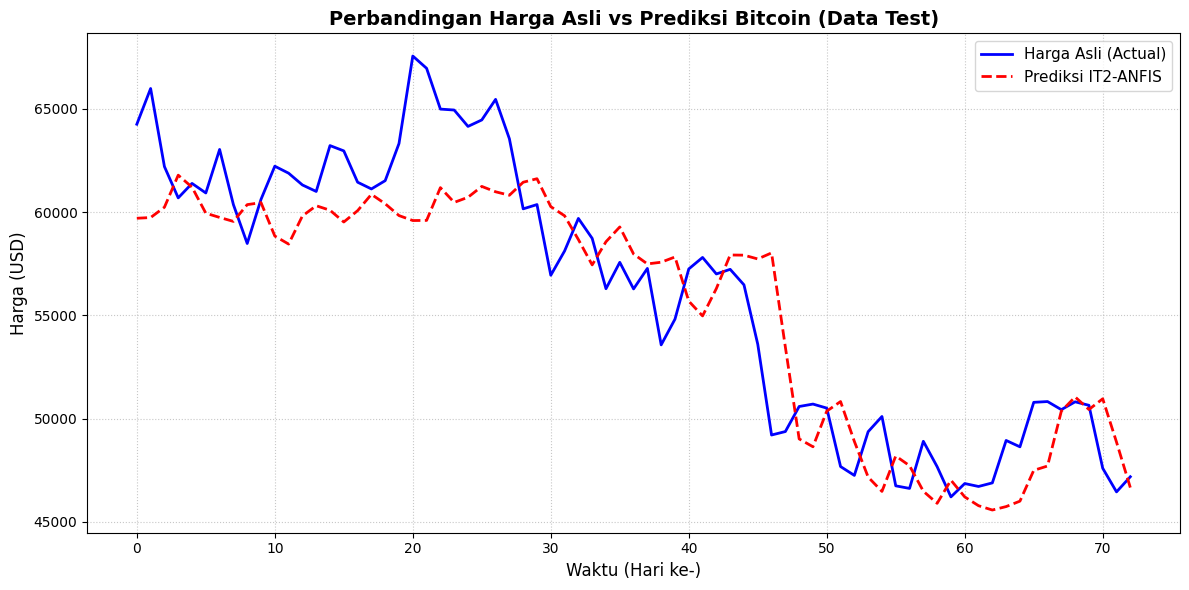

Runtime: 2 menit 56.30 detik


In [ ]:
start = time.time()
# --- 5. Main Execution ---
if __name__ == "__main__":
    LOOKBACK = 3 # Menggunakan 7 hari sebelumnya untuk prediksi

    # Asumsi fungsi load_bitcoin_data sudah didefinisikan sebelumnya
    X_train, X_test, y_train, y_test, scaler = load_bitcoin_data(lookback=LOOKBACK)

    # Inisialisasi Model (Input sesuai LOOKBACK, 2 MF per input)
    model = IT2_ANFIS(n_inputs=LOOKBACK, n_mf=2)

    print(f"Melatih model dengan {X_train.shape[0]} data...")
    # --- MENGGUNAKAN GRADIENT DESCENT ---
    # Anda bisa menyesuaikan nilai epochs dan learning_rate sesuai kebutuhan
    best_params = gradient_descent_optimize(model, X_train, y_train, epochs=50, learning_rate=0.01)

    # Prediksi pada Data Test
    y_pred_scaled = model.forward(X_test, best_params)

    # Denormalisasi untuk melihat harga asli
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_real = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Metrik Akhir
    rmse = calculate_rmse(y_test_real, y_pred_real)
    accuracy = calculate_accuracy(y_test_real, y_pred_real)

    print("\n" + "="*30)
    print("HASIL PREDIKSI BITCOIN (DATA TEST)")
    print(f"RMSE    : ${rmse:.2f}")
    print(f"Akurasi : {accuracy:.2f} %")
    print("="*30)

    # Contoh tampilan 5 prediksi terakhir
    print("\n5 Prediksi Terakhir vs Harga Asli:")
    for i in range(-5, 0):
        print(f"Asli: ${y_test_real[i]:.2f} | Prediksi: ${y_pred_real[i]:.2f}")

    # --- 6. Visualisasi Hasil ---
    print("\nMenampilkan grafik visualisasi...")
    plt.figure(figsize=(12, 6))

    # Plot harga asli (warna biru, garis tegas)
    plt.plot(y_test_real, label='Harga Asli (Actual)', color='blue', linewidth=2)

    # Plot harga prediksi (warna merah, garis putus-putus)
    plt.plot(y_pred_real, label='Prediksi IT2-ANFIS', color='red', linestyle='--', linewidth=2)

    # Konfigurasi tampilan grafik
    plt.title('Perbandingan Harga Asli vs Prediksi Bitcoin (Data Test)', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Hari ke-)', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    # Tampilkan grafik
    plt.show()


end = time.time()

elapsed = end - start
print(f"Runtime: {int(elapsed//60)} menit {elapsed%60:.2f} detik")

In [ ]:
best_params

array([ 0.04429032, -0.38294441, -0.1075502 ,  0.0919678 ,  0.38055769,
        0.10852037, -0.2333759 , -0.45897938,  0.38741671,  0.46913348,
        0.36927937, -0.41326393,  0.40167596, -0.12420454,  0.24608836,
       -0.07968083,  0.47186932,  0.3866876 ,  0.13334195, -0.21056499,
       -0.36952535, -0.18845135, -0.15114073, -0.1354188 ,  0.0409449 ,
       -0.46139682, -0.03406869,  0.20474221,  0.05395064, -0.24468835,
       -0.01583639,  0.1331727 , -0.28338722, -0.37164071,  0.15666182,
        0.02493616, -0.09472523, -0.20919086,  0.23632883,  0.40433764,
        0.3271707 ,  0.32644186, -0.46934073,  0.09242352,  0.27841356,
        0.49863451, -0.37022683,  0.4574586 , -0.30628606,  0.4526544 ])

### Menyimpan dan Memuat Model yang Sudah Dilatih

Anda dapat menyimpan parameter terbaik `best_params` yang dihasilkan dari proses pelatihan menggunakan `numpy.save`.
Ini memungkinkan Anda untuk memuat ulang model di kemudian hari tanpa perlu melatihnya lagi.

In [ ]:
import numpy as np

# Menyimpan parameter terbaik ke file
model_filename = 'it2_anfis_best_params.npy'
np.save(model_filename, best_params)
print(f"Parameter model disimpan ke: {model_filename}")

# Memuat kembali parameter model dari file
loaded_params = np.load(model_filename)
print(f"Parameter model berhasil dimuat dari: {model_filename}")

# Verifikasi bahwa parameter yang dimuat sama dengan yang disimpan
print(f"Apakah parameter yang dimuat sama? {np.array_equal(best_params, loaded_params)}")

# Contoh penggunaan parameter yang dimuat untuk prediksi
# y_pred_loaded_scaled = model.forward(X_test, loaded_params)
# y_pred_loaded_real = scaler.inverse_transform(y_pred_loaded_scaled.reshape(-1, 1)).flatten()
# rmse_loaded = calculate_rmse(y_test_real, y_pred_loaded_real)
# print(f"RMSE menggunakan parameter yang dimuat: ${rmse_loaded:.2f}")

In [ ]:
def gradient_descent_optimize(model, X, y, epochs=50, learning_rate=0.01):
    """
    Optimasi menggunakan Gradient Descent dengan hampiran numerik untuk mengatasi
    non-diferensiabilitas algoritma Karnik-Mendel.
    """
    dim = model.total_params
    # Inisialisasi parameter secara acak
    params = np.random.uniform(-0.5, 0.5, dim)

    epsilon = 1e-5 # Step kecil untuk menghitung turunan numerik

    # 1. Buat list kosong untuk menyimpan histori
    rmse_history = []

    for epoch in range(epochs):
        # Forward pass untuk menghitung error saat ini
        y_pred = model.forward(X, params)
        error = y_pred - y
        rmse = np.sqrt(np.mean(error**2))

        # 2. Simpan nilai RMSE epoch ini ke dalam histori
        rmse_history.append(rmse)

        # Hitung gradien untuk setiap parameter
        gradients = np.zeros(dim)
        for i in range(dim):
            # Simpan nilai asli
            orig_val = params[i]

            # Tambah epsilon (f(x + h))
            params[i] = orig_val + epsilon
            y_pred_plus = model.forward(X, params)
            loss_plus = np.mean((y_pred_plus - y)**2)

            # Kurangi epsilon (f(x - h))
            params[i] = orig_val - epsilon
            y_pred_minus = model.forward(X, params)
            loss_minus = np.mean((y_pred_minus - y)**2)

            # Kembalikan ke nilai asli
            params[i] = orig_val

            # Hitung gradien (Central Difference)
            gradients[i] = (loss_plus - loss_minus) / (2 * epsilon)

        # Update parameter menggunakan Gradient Descent standar
        params -= learning_rate * gradients

        print(f"Epoch {epoch+1}/{epochs} - RMSE: {rmse:.6f}")

    # 3. Kembalikan 2 nilai: parameter terbaik dan list historinya
    return params, rmse_history

In [ ]:
best_params, rmse_history = gradient_descent_optimize(model, X_train, y_train, epochs=100, learning_rate=0.05)

In [ ]:
# --- Tambahkan Visualisasi Konvergensi PSO ---
    plt.figure(figsize=(10, 5))
    plt.plot(rmse_history, color='tab:orange', linewidth=2, marker='o', markersize=4, markevery=5)
    plt.title('Kurva Konvergensi Optimasi Gradient Descent (Penurunan RMSE)', fontsize=14)
    plt.xlabel('Iterasi', fontsize=12)
    plt.ylabel('RMSE (Scaled)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()